In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import euclidean_distances, cosine_distances

In [ ]:
# 1. Load your dataset
df = pd.read_csv('/home/zeynepyavuz1621/zeynepyavuz1621-personal/REPOS/BIL476_DATA_MINING/PROJECT/SongRecommendationSystem/Data/SpotifyTracksDataset/encoded_preprocessed_dataset.csv')

In [90]:
# 2. Select ONLY the continuous audio features
# We leave out the 100+ genre columns to cluster purely by "sound"
audio_cols = ['acousticness', 'danceability', 'energy', 'instrumentalness',
              'liveness', 'speechiness', 'valence', 'loudness', 'tempo']

Calculating optimal clusters. This might take a few seconds...


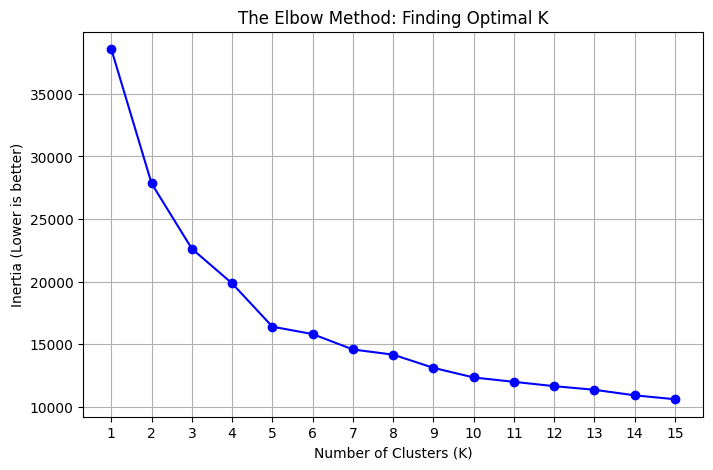

In [91]:
# FIND THE OPTIMAL NUMBER OF CLUSTERS
X = df[audio_cols]

# 3. Calculate "Inertia" (how tight the clusters are) for different K values
inertias = []
k_values = range(1, 16) # Testing 1 to 15 clusters

print("Calculating optimal clusters. This might take a few seconds...")
for k in k_values:
    # random_state=42 ensures you get the exact same results every time
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X)
    inertias.append(kmeans.inertia_)

# 4. Plot the graph
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker='o', linestyle='-', color='b')
plt.title('The Elbow Method: Finding Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Lower is better)')
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [92]:
# ==========================================
# PART 1: APPLY K-MEANS AND ADD CLUSTER IDs
# ==========================================
print("Running K-Means with K=6...")
optimal_k = 6

# Initialize the model with K=6
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')

# fit_predict assigns each song to a cluster and returns an array of the cluster IDs (0 to 5)
df_cluster = df.copy()
df_cluster['cluster_id'] = kmeans.fit_predict(X)

# Save the datas et with the new 'cluster_id' column
#df_cluster.to_csv('clustered_dataset.csv', index=False)
#print("Successfully saved clustered data to clustered_dataset.csv")

Running K-Means with K=6...


Reducing dimensions with PCA for visualization...


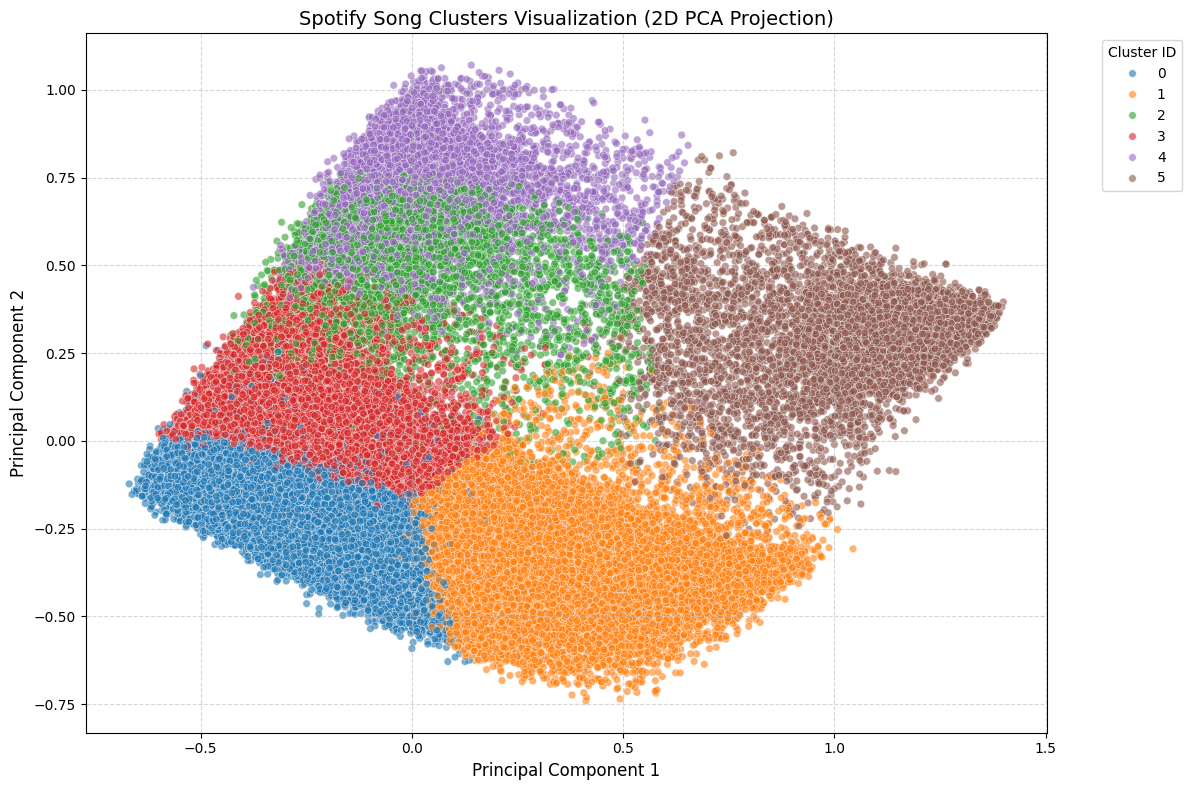

In [93]:
# ==========================================
# PART 2: VISUALIZE CLUSTERS USING PCA
# ==========================================
print("Reducing dimensions with PCA for visualization...")

# Initialize PCA to reduce our 10 features down to 2 dimensions (X and Y coordinates)
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X)

# Temporarily add the PCA coordinates to our dataframe for plotting
df_pca = df_cluster.copy()
df_pca['pca_x'] = pca_result[:, 0]
df_pca['pca_y'] = pca_result[:, 1]

# Set up the plot
plt.figure(figsize=(12, 8))

# Use Seaborn to create a scatter plot colored by 'cluster_id'
sns.scatterplot(
    x='pca_x', 
    y='pca_y',
    hue='cluster_id',
    palette='tab10',  # A color palette with distinct colors
    data=df_pca,
    s=30,             # Size of the dots
    alpha=0.6         # Slight transparency to see overlapping songs better
)

plt.title('Spotify Song Clusters Visualization (2D PCA Projection)', fontsize=14)
plt.xlabel('Principal Component 1', fontsize=12)
plt.ylabel('Principal Component 2', fontsize=12)
plt.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend outside the plot
plt.tight_layout() # Ensures labels don't get cut off
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [94]:
# ==========================================
# PART 3: RECOMMEND SONGS FROM CLUSTERS
# ==========================================

In [95]:
# Define Features
feature_cols = ['acousticness', 'danceability', 'energy', 'instrumentalness',
                'liveness', 'speechiness', 'valence', 
                'loudness', 'tempo']
genre_cols = [col for col in df.columns if col.startswith('genre_')]
cols = feature_cols + genre_cols

In [96]:
def get_user_vector_from_csv(user_df):
    """
    Reads a CSV file, calculates the average of the feature columns,
    and returns a single vector representing the user's taste.
    """
    user_features = user_df[cols]   
    # Calculate the Mean (Average) vector
    mean_vector = user_features.mean(axis=0)
    
    return mean_vector

In [97]:
# Recommender Engine
def recommend_from_vector(user_vector, k=10):
    """
    user_vector: A list of 10 numbers corresponding to feature_cols
    k: Number of recommendations to return
    """
    # Find the users cluster to recommend songs only from this scope
    user_vector_df = user_vector[audio_cols].to_frame().T
    predicted_cluster_array = kmeans.predict(user_vector_df)
    user_cluster_id = predicted_cluster_array[0]

    # Convert list to a 2D array for the math library
    # (The library expects a matrix, so we make a matrix of 1 row)
    target_matrix = [user_vector]
    
    # Calculate distance from YOUR vector to every song in the DB
    df_filtered = df_cluster[df_cluster['cluster_id'] == user_cluster_id].copy() # i made a new copy becuase using the same df again and again gives the fragmentation warning!
    print(df_filtered.shape)
    df_filtered['distance'] = euclidean_distances(df_filtered[cols], target_matrix)
    #df_filtered['distance'] = cosine_distances(df_filtered[cols], target_matrix)
    
    # Sort by smallest distance
    recommendations = df_filtered.sort_values('distance').head(k)
    return recommendations[['artists', 'track_name', 'distance', 'track_genre']]

In [98]:
user_df = pd.read_csv('/home/zeynepyavuz1621/zeynepyavuz1621-personal/REPOS/BIL476_DATA_MINING/PROJECT/SongRecommendationSystem/Recommender/user_input.csv')
user_vector = get_user_vector_from_csv(user_df)
num_of_recommendations = 20

print("--- Recommendations for My Custom Vibe ---")
print(recommend_from_vector(user_vector, num_of_recommendations))

--- Recommendations for My Custom Vibe ---
(23379, 135)
                                    artists  \
16425             Camila Cabello;Ed Sheeran   
16504                          Zara Larsson   
16168  Bruno Mars;Anderson .Paak;Silk Sonic   
16336                Tiësto;Stevie Appleton   
16176      David Guetta;Bebe Rexha;J Balvin   
16296                   Shakira;Wyclef Jean   
16304                      Deep Chills;IVIE   
16340                          Tiësto;Mabel   
16128                          Charlie Puth   
16137                              Dua Lipa   
16130                              Doja Cat   
16139          Gym Class Heroes;Adam Levine   
16147           benny blanco;BTS;Snoop Dogg   
25309                         Alex & Daniel   
20880                               Baciary   
24504   Calvin Harris;Charlie Puth;Shenseea   
47467                             Creep Hyp   
66919                          Oscar D'León   
69985                            Sr. Bikini   
4988